# 1 &middot; Library Fundamentals

This first notebook introduces the **data containers** of `jax_fli` and how to move
between them &mdash; *without* running a simulation. We deliberately use a trivial particle
distribution (a uniform grid with a little jitter) so that nothing distracts from the objects
themselves.

You will learn:

1. The four `Field` types and the metadata they carry
2. How to **paint** particles onto a 3D box, a flat-sky map, and a HEALPix sphere
3. How to measure a **power spectrum** from each painted field (and why you convert to
   *overdensity* first)
4. What the **convergence / shear** subfields are (covered fully in the
   [Lensing notebook](../2-advanced-usage/07-Lensing.ipynb))
5. How to **save and load** results with the `Catalog` container

Clustering, lightcones and gravity arrive in the next notebooks
([LPT](02-LPT-Simulation.ipynb), [PM](03-PM-Simulation.ipynb)).

## Setup

In [1]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## The `Field` family

Every quantity in `jax_fli` lives in an immutable [Equinox](https://github.com/patrick-kidger/equinox)
PyTree that subclasses `AbstractField`. There are four concrete types:

| Type | Holds | Shape |
|------|-------|-------|
| `ParticleField` | particle positions / displacements | `(X, Y, Z, 3)` |
| `DensityField` | a 3D density box | `(X, Y, Z)` |
| `FlatDensity` | a 2D flat-sky map | `(npix_y, npix_x)` |
| `SphericalDensity` | a HEALPix map | `(npix,)` |

Because they are PyTrees, every field is safe to `jit`, `vmap` and `grad`, and any field can be
**batched** by adding a single leading axis (e.g. a stack of lightcone shells).

### Static metadata (simulation settings)

- `mesh_size: (int, int, int)` &mdash; grid shape for densities, or particle count per axis.
- `box_size: (float, float, float)` &mdash; physical box size in comoving Mpc/h.
- `observer_position: (float, float, float)` &mdash; observer location as a **fraction** of the
  box. `(0.5, 0.5, 0.5)` is the centre; `(0, 0, 0)` is a corner.

### Output-map geometry

- `nside` &mdash; HEALPix resolution (`SphericalDensity` only).
- `flatsky_npix: (int, int)` &mdash; pixel count (`FlatDensity` only).
- `field_size` &mdash; physical/angular size of the flat-sky map (`FlatDensity` only).

These may be `None` for field types that do not use them.

### Units

Positions use `jfli.units.PositionUnit`:

- `GRID_RELATIVE` &mdash; **displacement** from the underlying uniform grid (the default; the
  integer grid is only added internally at paint time, which is memory-efficient and
  distribution-friendly).
- `GRID_ABSOLUTE` &mdash; absolute grid coordinates in `[0, N_mesh)`.
- `MPC_H` &mdash; comoving Mpc/h (must be converted to a grid unit before painting).

Densities use `jfli.units.DensityUnit`: `DENSITY`, `OVERDENSITY` ($\delta=\rho/\bar\rho-1$),
`COUNTS`, `MSUN_H_PER_MPC3`. Convert with `field.to(target_unit)`.

### Dynamic metadata (traced by JAX)

`z_sources`, `scale_factors`, `comoving_centers`, `density_width` describe *where on the
lightcone* a map sits. Simulations (`lpt`, `nbody`) fill these in automatically; you normally
only read them. We will set them by hand at the end, when we serialize a hand-painted map.

`field.name` is a free-form label used when cataloging. `field_sharding` / `halo_size` control
multi-device layout (see the [Distributed PM notebook](04-Distributed-PM.ipynb)).

## A trivial particle set: uniform grid + jitter

Instead of simulating, we build a `ParticleField` **directly**. In `GRID_RELATIVE` units the
array stores *displacements* from the uniform grid, so a uniform distribution is simply an
array of (small) random offsets &mdash; zero displacement would be a perfect grid, and a little
Gaussian *jitter* avoids the perfectly regular pattern.

In [2]:
key = jax.random.PRNGKey(42)

mesh_size = (256, 256, 256)       # 256**3 particles
box_size = (1000.0, 1000.0, 1000.0)  # Mpc/h
nside = 256                       # HEALPix resolution for the spherical map
flatsky_npix = (256, 256)         # flat-sky map resolution
field_size = (10.0, 10.0)         # flat-sky map size
cosmo = jc.Planck18()

# Sub-cell Gaussian jitter (in grid-cell units) around the uniform grid
jitter = 0.2 * jax.random.normal(key, (*mesh_size, 3))

particles = jfli.ParticleField(
    array=jitter,
    mesh_size=mesh_size,
    box_size=box_size,
    nside=nside,
    flatsky_npix=flatsky_npix,
    field_size=field_size,
    unit=jfli.units.GRID_RELATIVE,
    name="uniform_jitter",
)
print(f"type   : {type(particles).__name__}")
print(f"unit   : {particles.unit}")
print(f"shape  : {particles.array.shape}")

type   : ParticleField
unit   : PositionUnit.GRID_RELATIVE
shape  : (64, 64, 64, 3)


### Visualizing the particles

Any field has a `.show()` helper. For particles we **thin** the cloud (plot every Nth point)
so the scatter stays legible.

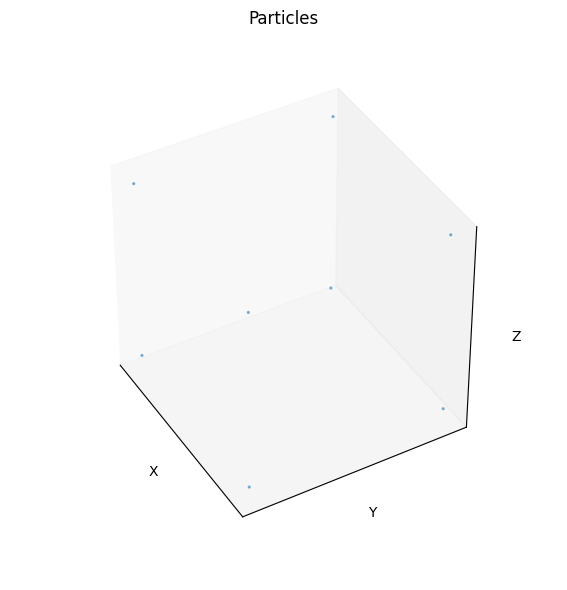

In [3]:
particles.to(jfli.units.GRID_ABSOLUTE).show(thinning=40)

## Painting

*Painting* deposits particles onto a grid with a mass-assignment kernel. The same particles can
be painted onto three different geometries:

| Target | Method | Output |
|--------|--------|--------|
| 3D box | `.paint()` | `DensityField` |
| flat sky | `.paint_2d(center, density_plane_width)` | `FlatDensity` |
| sphere | `.paint_spherical(center, density_plane_width, scheme=...)` | `SphericalDensity` |

The flat and spherical painters need a **shell**: a `center` (its comoving distance from the
observer) and a `density_plane_width` (its thickness). The Cartesian painters use Cloud-in-Cell
(CIC); the spherical painter offers `ngp`, `bilinear` (default) and `rbf_neighbor`.

In [4]:
r_center = 300.0       # comoving distance to the shell [Mpc/h]
shell_width = 150.0    # shell thickness [Mpc/h]

### 3D density

`.paint()` returns a `DensityField`. A near-uniform particle set produces a near-uniform box,
so we stretch with `log(1 + n)` to reveal the small Poisson fluctuations.

DensityField: shape=(64, 64, 64), unit=DensityUnit.DENSITY


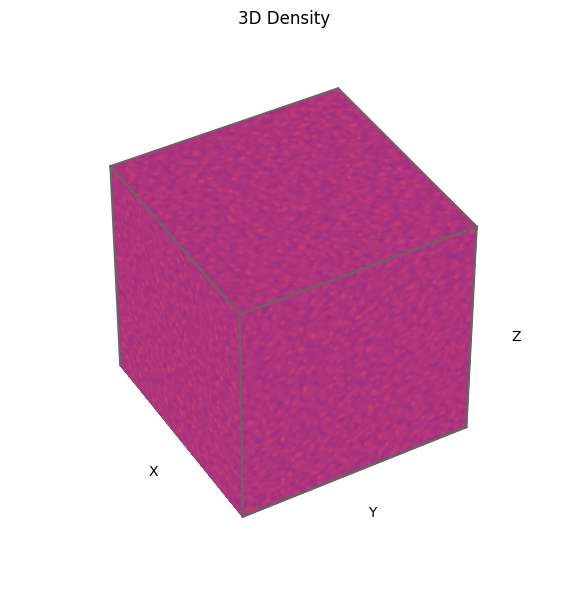

In [5]:
density_3d = particles.paint()
print(f"{type(density_3d).__name__}: shape={density_3d.array.shape}, unit={density_3d.unit}")
density_3d.apply_fn(jnp.log1p).show(colorbar=False, project_slices=16)

### Flat-sky map

`.paint_2d()` projects the particles inside the shell onto a small tangent-plane image.

FlatDensity: shape=(128, 128), unit=DensityUnit.DENSITY


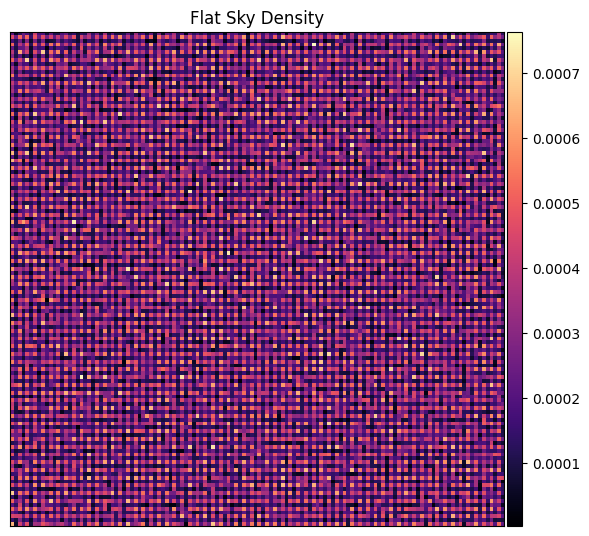

In [6]:
flat_map = particles.paint_2d(center=r_center, density_plane_width=shell_width)
print(f"{type(flat_map).__name__}: shape={flat_map.array.shape}, unit={flat_map.unit}")
flat_map.show()

### Spherical (HEALPix) map

`.paint_spherical()` projects the shell onto a full-sky HEALPix map. We use the `ngp` scheme
here because it has a closed-form pixel window we can later deconvolve (see the
[LPT notebook](02-LPT-Simulation.ipynb)).

SphericalDensity: shape=(49152,), nside=64


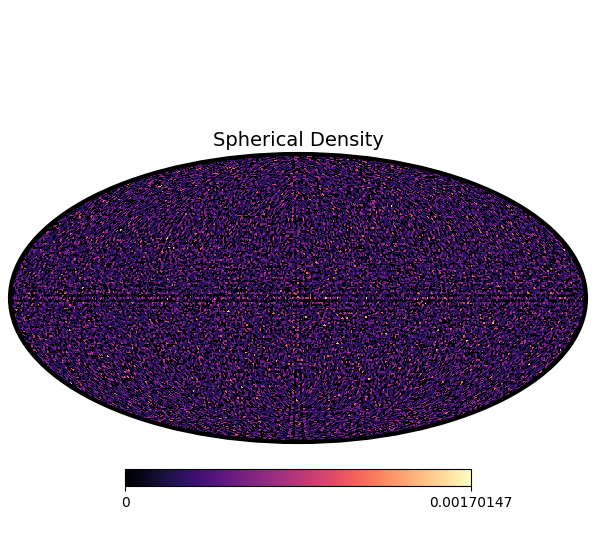

In [7]:
spherical_map = particles.paint_spherical(
    center=r_center, density_plane_width=shell_width, scheme="ngp"
)
print(f"{type(spherical_map).__name__}: shape={spherical_map.array.shape}, nside={spherical_map.nside}")
spherical_map.apply_fn(jnp.log1p).show()

## Power spectra

A `ParticleField` has **no** spectrum method &mdash; you always paint first, then measure on the
grid. The three painted fields expose:

- `DensityField.power()` &rarr; 3D $P(k)$
- `FlatDensity.angular_cl()` and `SphericalDensity.angular_cl()` &rarr; angular $C_\ell$

Angular spectra are defined for the **overdensity** $\delta$, so we convert the maps with
`.to(jfli.units.OVERDENSITY)` first (this divides by the mean and subtracts 1, using the
default global normalization). Our particles are *unclustered*, so every spectrum should be
roughly flat &mdash; pure shot noise. Real cosmological structure (and agreement with theory)
shows up once we add gravity in the next notebooks.

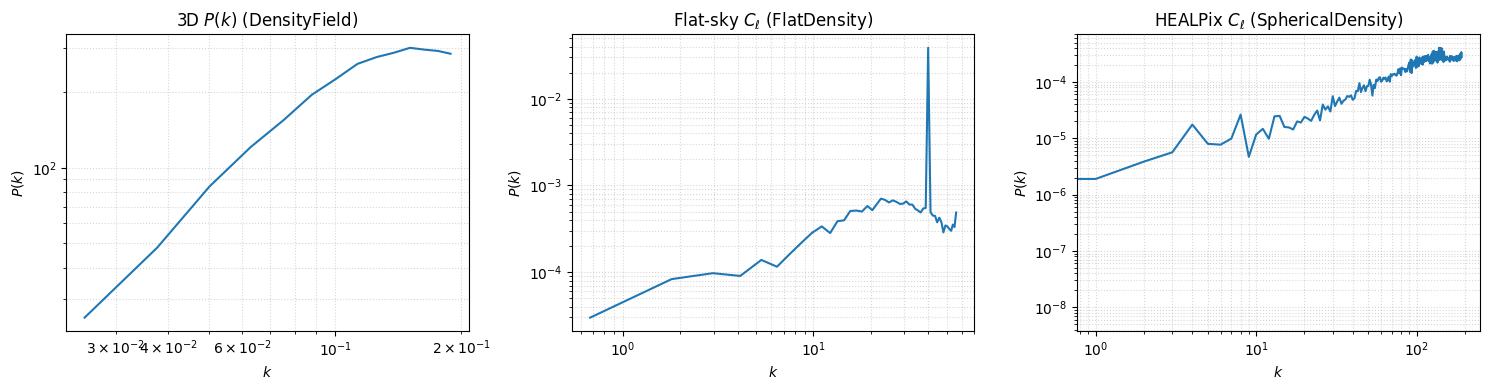

In [8]:
pk = density_3d.power()                                   # 3D P(k)
cl_flat = flat_map.to(jfli.units.OVERDENSITY).angular_cl()  # flat-sky C_ell
cl_sph = spherical_map.to(jfli.units.OVERDENSITY).angular_cl(method="healpy")  # HEALPix C_ell

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pk.plot(ax=axes[0], logx=True, logy=True)
axes[0].set_title("3D $P(k)$ (DensityField)")
cl_flat.plot(ax=axes[1], logx=True, logy=True)
axes[1].set_title(r"Flat-sky $C_\ell$ (FlatDensity)")
cl_sph.plot(ax=axes[2], logx=True, logy=True)
axes[2].set_title(r"HEALPix $C_\ell$ (SphericalDensity)")
plt.tight_layout()
plt.show()

## Subfields: convergence $\kappa$ and shear $\gamma$

Two specialised maps appear later in the pipeline:

- `FlatKappaField` / `SphericalKappaField` &mdash; weak-lensing **convergence** $\kappa$
  (a projected-mass map). They *subclass* the density maps above, so everything you just
  learned (painting metadata, `.angular_cl()`, cataloging) applies directly.
- `FlatShearField` / `SphericalShearField` &mdash; the **shear** $\gamma_1, \gamma_2$, obtained
  from a convergence map with `kappa.get_shear()`.

We do not build them here because they come from a lensed lightcone; see the
[Lensing notebook](../2-advanced-usage/07-Lensing.ipynb).

## Saving & loading: the `Catalog`

`jfli.io.Catalog` bundles one or more fields with their cosmology and serializes to **Parquet**
(and, via 🤗 `datasets`, to the Hugging Face Hub). It works for both **field** maps and
**spectra**.

> Requires `pip install jax-fli[catalog]`.

A catalog records lightcone *provenance* (`scale_factors`, `z_sources`, `comoving_centers`,
`density_width`). A simulation fills these automatically; because we painted by hand we attach
them ourselves from the shell geometry.

In [9]:
# Provenance for the hand-painted shell
a_shell = jc.background.a_of_chi(cosmo, r_center)
z_shell = 1.0 / a_shell - 1.0
spherical_map = spherical_map.replace(
    scale_factors=jnp.atleast_1d(a_shell),
    z_sources=jnp.atleast_1d(z_shell),
    comoving_centers=jnp.atleast_1d(r_center),
    density_width=jnp.atleast_1d(shell_width),
)

# Save & reload a FIELD
field_cat = jfli.io.Catalog(field=spherical_map, cosmology=cosmo)
field_cat.to_parquet("basics_field.parquet")
reloaded = jfli.io.Catalog.from_parquet("basics_field.parquet")
print("field catalog ->", type(reloaded.field[0]).__name__, "| z =", float(jnp.atleast_1d(reloaded.field[0].z_sources)[0]))

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

field catalog -> SphericalDensity | z = 0.10255622863769531


The same container stores a **spectrum**. A `PowerSpectrum` already carries its own metadata,
so no manual step is needed.

In [10]:
# Save & reload a SPECTRUM
spec_cat = jfli.io.Catalog(field=cl_sph, cosmology=cosmo)
spec_cat.to_parquet("basics_spectrum.parquet")
reloaded_spec = jfli.io.Catalog.from_parquet("basics_spectrum.parquet")
print("spectrum catalog ->", type(reloaded_spec.field[0]).__name__)

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Generating train split: 0 examples [00:00, ? examples/s]

spectrum catalog -> PowerSpectrum


## Next steps

- [02 &middot; LPT Simulation](02-LPT-Simulation.ipynb) &mdash; displace particles with gravity,
  build a lightcone, and compare to theory.
- [03 &middot; PM Simulation](03-PM-Simulation.ipynb) &mdash; full N-body with the BullFrog solver.
- [04 &middot; Distributed PM](04-Distributed-PM.ipynb) &mdash; scale across devices with sharding.